In [ ]:
!pip install gdown
!gdown --id 1ieMX1DUm4G1R8X9_rGXz3OXHfoEChNu8 --output /content/Ship_datasets.zip

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:132: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1ieMX1DUm4G1R8X9_rGXz3OXHfoEChNu8
From (redirected): https://drive.google.com/uc?id=1ieMX1DUm4G1R8X9_rGXz3OXHfoEChNu8&confirm=t&uuid=14076fbb-14ae-4925-9d4f-6baac6fec598
To: /content/Ship_datasets.zip
100% 84.8M/84.8M [00:05<00:00, 16.9MB/s]


In [ ]:
import os
import zipfile
import pandas as pd

zip_file_path = '/content/Ship_datasets.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
train_dir = '/content/train/'

train_images_dir = os.path.join(train_dir, 'images')

print(train_images_dir)

/content/train/images


In [ ]:
train_images_fnames = os.listdir(train_images_dir)

In [ ]:
print(train_images_fnames[:5])

['2784168.jpg', '2828762.jpg', '2784235.jpg', '2841625.jpg', '1533107.jpg']


In [ ]:
train_csv = '/content/train/train.csv'

images_folder = '/content/train/images'

df = pd.read_csv(train_csv)

In [ ]:
df['image_path'] = df['image'].apply(lambda x: os.path.join(images_folder, x))

In [ ]:
images_file = set(os.listdir(images_folder))

df = df[df['image'].isin(images_file)]

In [ ]:
df.head(5)

,image,category,image_path
0,2823080.jpg,1,/content/train/images/2823080.jpg
1,2870024.jpg,1,/content/train/images/2870024.jpg
2,2662125.jpg,2,/content/train/images/2662125.jpg
3,2900420.jpg,3,/content/train/images/2900420.jpg
4,2804883.jpg,2,/content/train/images/2804883.jpg


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6252 entries, 0 to 6251
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image       6252 non-null   object
 1   category    6252 non-null   int64 
 2   image_path  6252 non-null   object
dtypes: int64(1), object(2)
memory usage: 146.7+ KB


In [ ]:
df = df.astype({'category': 'str'})

## 데이터 전처리 EDA

In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['category'])

In [ ]:
print(train_df['category'].value_counts())

category
1    1696
5     973
2     933
3     733
4     666
Name: count, dtype: int64


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)

validation_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_dataframe(train_df,
                                                    x_col = 'image_path',
                                                    y_col = 'category',
                                                    batch_size = 32,
                                                    target_size = (150, 150),
                                                    class_mode = 'categorical')

validation_generator = validation_datagen.flow_from_dataframe(val_df,
                                                              x_col = 'image_path',
                                                              y_col = 'category',
                                                              batch_size = 32,
                                                              target_size = (150, 150),
                                                              class_mode = 'categorical')

Found 5001 validated image filenames belonging to 5 classes.
Found 1251 validated image filenames belonging to 5 classes.


## 모델 구성

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Input, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Input(shape=(150,150,3)))
model.add(Conv2D(filters = 32, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters = 32, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size = (2,2), strides = 2, padding = 'same'))
model.add(Dropout(0,2))

model.add(Conv2D(filters = 64, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters = 64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size = (2,2), strides = 2, padding = 'same'))
model.add(Dropout(0,2))

model.add(Conv2D(filters = 128, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters = 128, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size = (2,2), strides = 2, padding = 'same'))
model.add(Dropout(0,2))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(5, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 150, 150, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 150, 150, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 75, 75, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 75, 75, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 38, 38, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 38, 38, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 38, 38, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 38, 38, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 19, 19, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 19, 19, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 46208)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │      11,829,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,117,797 (46.23 MB)

 Trainable params: 12,117,797 (46.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer = 'adam',
              loss = 'categorical_crossentropy',
              metrics = ['acc'])

In [ ]:
history = model.fit(train_generator,
                    epochs = 30,
                    batch_size = 32,
                    validation_data = validation_generator)

Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - acc: 0.3372 - loss: 1.5382 - val_acc: 0.4373 - val_loss: 1.2914
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - acc: 0.4745 - loss: 1.2047 - val_acc: 0.5468 - val_loss: 1.0894
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - acc: 0.6277 - loss: 0.9423 - val_acc: 0.6547 - val_loss: 0.8621
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - acc: 0.7598 - loss: 0.6367 - val_acc: 0.6914 - val_loss: 0.8272
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - acc: 0.8535 - loss: 0.4122 - val_acc: 0.6643 - val_loss: 1.0268
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - acc: 0.9124 - loss: 0.2358 - val_acc: 0.6835 - val_loss: 1.2365
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 81ms/step - acc: 0.9666 - loss: 0.0993 - val_acc: 0.6978 - val_loss: 1.3629
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 71ms/step - acc: 0.9825 - loss: 0.0536 - val_acc: 0.6962 - val_loss: 1.8321
Epoch 9/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/st

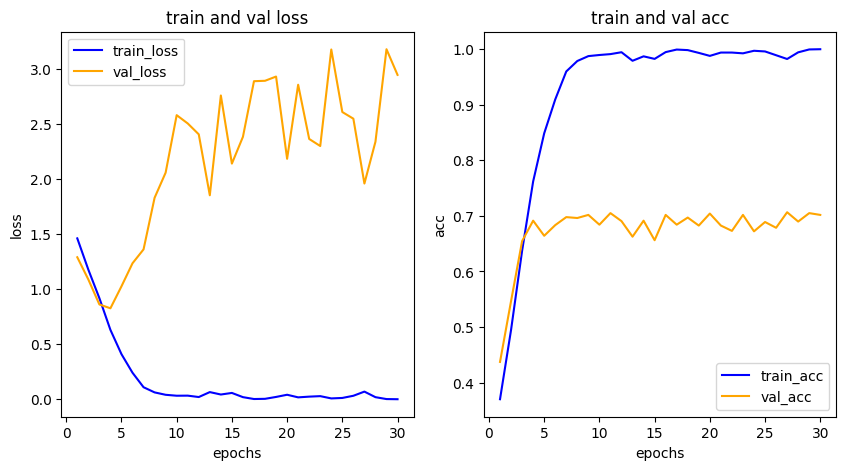

In [ ]:
import matplotlib.pyplot as plt

his_dict = history.history
loss = his_dict['loss']
val_loss = his_dict['val_loss']

epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize=(10, 5))

# 훈련 및 검증 손실 그리기
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color = 'blue', label='train_loss')
ax1.plot(epochs, val_loss, color = 'orange', label='val_loss')
ax1.set_title('train and val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

acc = his_dict['acc']
val_acc = his_dict['val_acc']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color = 'blue', label='train_acc')
ax2.plot(epochs, val_acc, color = 'orange', label='val_acc')
ax2.set_title('train and val acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()

## 이미지 증식


In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   horizontal_flip =True,
                                   zoom_range = 0.2,
                                   width_shift_range = 0.1,
                                   height_shift_range = 0.1,
                                   rotation_range = 30,
                                   fill_mode = 'nearest')

validation_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_dataframe(train_df,
                                                    x_col = 'image_path',
                                                    y_col = 'category',
                                                    batch_size = 32,
                                                    target_size = (150, 150),
                                                    class_mode = 'categorical')

validation_generator = validation_datagen.flow_from_dataframe(val_df,
                                                              x_col = 'image_path',
                                                              y_col = 'category',
                                                              batch_size = 32,
                                                              target_size = (150, 150),
                                                              class_mode = 'categorical')

Found 5001 validated image filenames belonging to 5 classes.
Found 1251 validated image filenames belonging to 5 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Input, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Input(shape=(150,150,3)))
model.add(Conv2D(filters = 32, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters = 32, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size = (2,2), strides = 2, padding = 'same'))
model.add(Dropout(0,2))

model.add(Conv2D(filters = 64, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters = 64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size = (2,2), strides = 2, padding = 'same'))
model.add(Dropout(0,2))

model.add(Conv2D(filters = 128, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters = 128, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size = (2,2), strides = 2, padding = 'same'))
model.add(Dropout(0,2))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(5, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 150, 150, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 150, 150, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 75, 75, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 75, 75, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 38, 38, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 38, 38, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 38, 38, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 38, 38, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 19, 19, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 19, 19, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 46208)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      11,829,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,117,797 (46.23 MB)

 Trainable params: 12,117,797 (46.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer = 'adam',
              loss = 'categorical_crossentropy',
              metrics = ['acc'])

In [ ]:
history = model.fit(train_generator,
                    epochs = 30,
                    batch_size = 32,
                    validation_data = validation_generator)

Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 273ms/step - acc: 0.3270 - loss: 1.5920 - val_acc: 0.4053 - val_loss: 1.3670
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 62s 210ms/step - acc: 0.3916 - loss: 1.3847 - val_acc: 0.4772 - val_loss: 1.2139
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 45s 275ms/step - acc: 0.4556 - loss: 1.2501 - val_acc: 0.4748 - val_loss: 1.1769
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 73s 224ms/step - acc: 0.4920 - loss: 1.1780 - val_acc: 0.5476 - val_loss: 1.0575
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 227ms/step - acc: 0.5640 - loss: 1.0800 - val_acc: 0.5723 - val_loss: 1.0342
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 43s 243ms/step - acc: 0.5866 - loss: 1.0025 - val_acc: 0.5739 - val_loss: 1.0002
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 224ms/step - acc: 0.6086 - loss: 0.9662 - val_acc: 0.6435 - val_loss: 0.8533
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 35s 215ms/step - acc: 0.6422 - loss: 0.8822 - val_acc: 0.6507 - val_loss: 0.8996
Epoch 9/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 42s

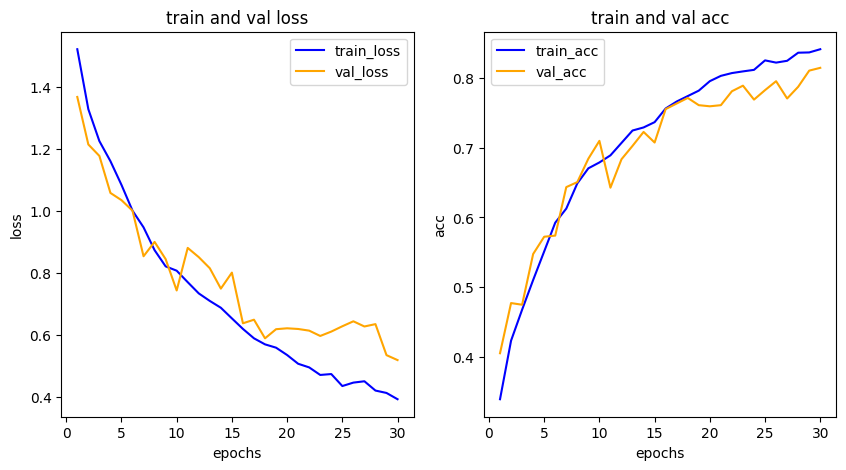

In [ ]:
his_dict = history.history
loss = his_dict['loss']
val_loss = his_dict['val_loss']

epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize=(10, 5))

# 훈련 및 검증 손실 그리기
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color = 'blue', label='train_loss')
ax1.plot(epochs, val_loss, color = 'orange', label='val_loss')
ax1.set_title('train and val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

acc = his_dict['acc']
val_acc = his_dict['val_acc']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color = 'blue', label='train_acc')
ax2.plot(epochs, val_acc, color = 'orange', label='val_acc')
ax2.set_title('train and val acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()

## 전이학습


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)

validation_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_dataframe(train_df,
                                                    x_col = 'image_path',
                                                    y_col = 'category',
                                                    batch_size = 32,
                                                    target_size = (150, 150),
                                                    class_mode = 'categorical')

validation_generator = validation_datagen.flow_from_dataframe(val_df,
                                                              x_col = 'image_path',
                                                              y_col = 'category',
                                                              batch_size = 32,
                                                              target_size = (150, 150),
                                                              class_mode = 'categorical')

Found 5001 validated image filenames belonging to 5 classes.
Found 1251 validated image filenames belonging to 5 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Input, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16

vgg16 = VGG16(weights = 'imagenet', input_shape = (150,150,3), include_top = False)
vgg16.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 150, 150, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 150, 150, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 75, 75, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 75, 75, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 75, 75, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 37, 37, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 37, 37, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 37, 37, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 37, 37, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 18, 18, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 18, 18, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 9, 9, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = Sequential()
model.add(Input(shape=(150,150,3)))

model.add(vgg16)

model.add(Flatten())
model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dense(5, activation='softmax'))

In [ ]:
model.compile(optimizer = 'adam',
              loss = 'categorical_crossentropy',
              metrics = ['acc'])


In [ ]:
history = model.fit(train_generator,
                    epochs = 30,
                    validation_data = validation_generator)

Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 85s 386ms/step - acc: 0.3569 - loss: 1.5646 - val_acc: 0.3605 - val_loss: 1.9513
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 261ms/step - acc: 0.5060 - loss: 1.1895 - val_acc: 0.4237 - val_loss: 1.7248
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 81s 256ms/step - acc: 0.5864 - loss: 1.0319 - val_acc: 0.5196 - val_loss: 1.1212
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 253ms/step - acc: 0.6424 - loss: 0.8947 - val_acc: 0.6427 - val_loss: 0.9714
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 253ms/step - acc: 0.6930 - loss: 0.7705 - val_acc: 0.5891 - val_loss: 0.9913
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 253ms/step - acc: 0.7310 - loss: 0.6651 - val_acc: 0.6691 - val_loss: 0.8392
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - acc: 0.7335 - loss: 0.6569 - val_acc: 0.4013 - val_loss: 2.9062
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - acc: 0.7879 - loss: 0.5429 - val_acc: 0.6882 - val_loss: 0.8975
Epoch 9/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s

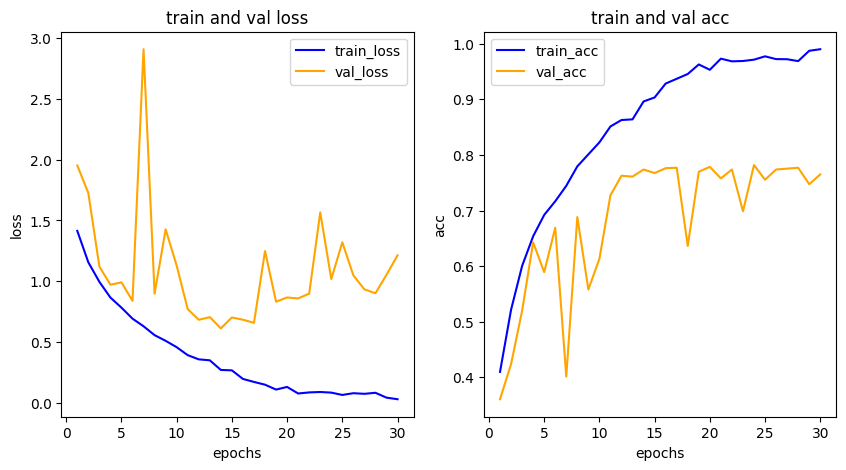

In [ ]:
his_dict = history.history
loss = his_dict['loss']
val_loss = his_dict['val_loss']

epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize=(10, 5))

# 훈련 및 검증 손실 그리기
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color = 'blue', label='train_loss')
ax1.plot(epochs, val_loss, color = 'orange', label='val_loss')
ax1.set_title('train and val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

acc = his_dict['acc']
val_acc = his_dict['val_acc']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color = 'blue', label='train_acc')
ax2.plot(epochs, val_acc, color = 'orange', label='val_acc')
ax2.set_title('train and val acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()

## 예측

In [ ]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def pred(fname):
  category_label = {1: 'Cargo', 2: 'Military', 3: 'Carrier', 4: 'Cruise', 5: 'Tankers'}
  img = image.load_img(fname, target_size=(150,150))
  plt.imshow(img)
  x = image.img_to_array(img)/255
  images = np.expand_dims(x, axis=0)
  classes = model.predict(images, batch_size=1)
  classes_label = np.argmax(classes, axis=-1)[0] + 1
  if classes_label == 1:
    print(f'{fname} 이 사진의 선박 종류는 {category_label[classes_label]} 입니다.')
  elif classes_label == 2:
    print(f'{fname} 이 사진의 선박 종류는 {category_label[classes_label]} 입니다.')
  elif classes_label == 3:
    print(f'{fname} 이 사진의 선박 종류는 {category_label[classes_label]} 입니다.')
  elif classes_label == 4:
    print(f'{fname} 이 사진의 선박 종류는 {category_label[classes_label]} 입니다.')
  elif classes_label == 5:
    print(f'{fname} 이 사진의 선박 종류는 {category_label[classes_label]} 입니다.')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
/content/train/images/1182765.jpg 이 사진의 선박 종류는 Cruise 입니다.


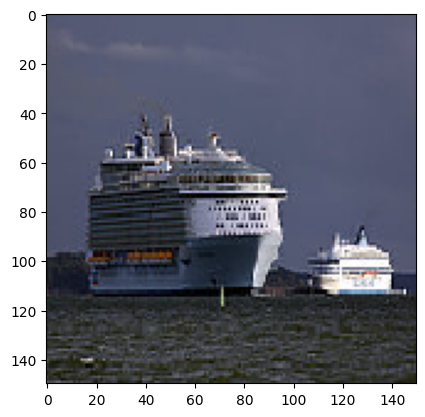

In [ ]:
pred('/content/train/images/1182765.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
/content/train/images/1417878.jpg 이 사진의 선박 종류는 Cargo 입니다.


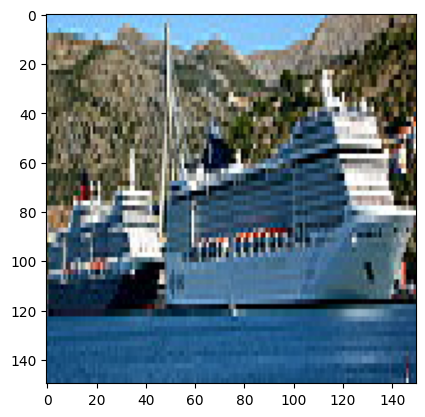

In [ ]:
pred('/content/train/images/1417878.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
/content/train/images/2843780.jpg 이 사진의 선박 종류는 Tankers 입니다.


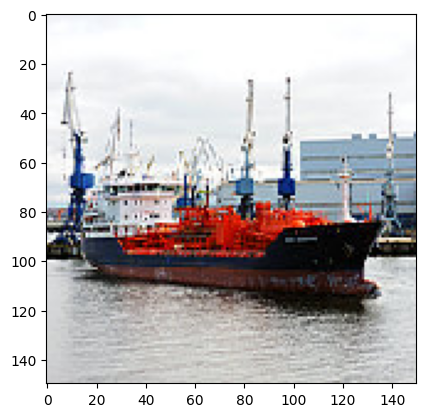

In [ ]:
pred('/content/train/images/2843780.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
/content/train/images/2872157.jpg 이 사진의 선박 종류는 Cargo 입니다.


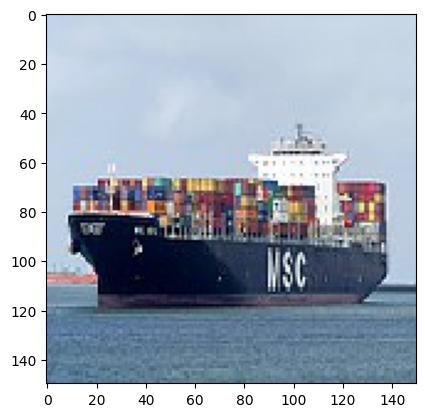

In [ ]:
pred('/content/train/images/2872157.jpg')

In [ ]:
uploaded = files.upload()


Saving 215373_133708_2919.jpg to 215373_133708_2919.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
/content/215373_133708_2919.jpg 이 사진의 선박 종류는 Tankers 입니다.


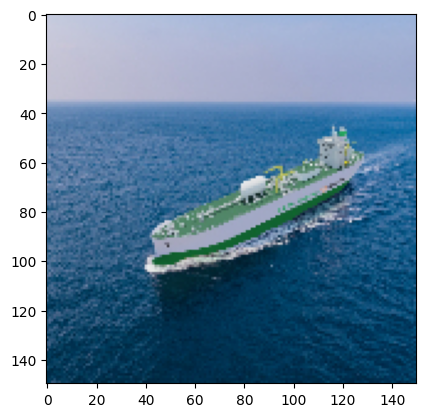

In [ ]:
pred('/content/215373_133708_2919.jpg')